In [114]:
## Author: Gracie Grimsrud
## Date: 09/16/2027

In [115]:
from pathlib import Path

import nibabel as nib
import numpy as np
import pandas as pd

from nibabel.cifti2 import Cifti2Header
from nibabel.cifti2.cifti2_axes import BrainModelAxis, ScalarAxis

In [116]:
base_directory = Path(
    "/oak/stanford/groups/russpold/users/grimsrud/projects/pfm_compare/analysis/temp_match_results"
)

subject = "sub-s19"
session = "ses-concatenated"

common_suffix = (
    "ReproTM_template-ABCC2026-a3-9to16_refine-SCAN_minsize-30.dscalar.nii"
)

In [117]:
input_config = {
    "rest": {
        "results_directory": "april_2026_fmriprep_xcpd",
        "task": "rest",
    },
    "task": {
        "results_directory": "april_2026_fmriprep_xcpd",
        "task": "task",
    },
    "task_resid_raw": {
        "results_directory": "july2026_raw_resid",
        "task": "taskresidRAW",
    },
}

In [118]:
def build_dscalar_path(results_directory, task):
    filename = (
        f"{subject}_{session}_task-{task}_"
        f"{common_suffix}"
    )

    return (
        base_directory
        / results_directory
        / subject
        / f"task-{task}"
        / subject
        / session
        / "func"
        / filename
    )

In [119]:
input_files = {
    input_name: build_dscalar_path(
        results_directory=config["results_directory"],
        task=config["task"],
    )
    for input_name, config in input_config.items()
}

In [120]:
for name, path in input_files.items():
    print(f"{name}:")
    print(f"  {path}")
    print()

rest:
  /oak/stanford/groups/russpold/users/grimsrud/projects/pfm_compare/analysis/temp_match_results/april_2026_fmriprep_xcpd/sub-s19/task-rest/sub-s19/ses-concatenated/func/sub-s19_ses-concatenated_task-rest_ReproTM_template-ABCC2026-a3-9to16_refine-SCAN_minsize-30.dscalar.nii

task:
  /oak/stanford/groups/russpold/users/grimsrud/projects/pfm_compare/analysis/temp_match_results/april_2026_fmriprep_xcpd/sub-s19/task-task/sub-s19/ses-concatenated/func/sub-s19_ses-concatenated_task-task_ReproTM_template-ABCC2026-a3-9to16_refine-SCAN_minsize-30.dscalar.nii

task_resid_raw:
  /oak/stanford/groups/russpold/users/grimsrud/projects/pfm_compare/analysis/temp_match_results/july2026_raw_resid/sub-s19/task-taskresidRAW/sub-s19/ses-concatenated/func/sub-s19_ses-concatenated_task-taskresidRAW_ReproTM_template-ABCC2026-a3-9to16_refine-SCAN_minsize-30.dscalar.nii



In [121]:
for name, path in input_files.items():
    if path.is_file():
        print(f"FOUND   {name}: {path.name}")
    else:
        print(f"MISSING {name}: {path}")

FOUND   rest: sub-s19_ses-concatenated_task-rest_ReproTM_template-ABCC2026-a3-9to16_refine-SCAN_minsize-30.dscalar.nii
FOUND   task: sub-s19_ses-concatenated_task-task_ReproTM_template-ABCC2026-a3-9to16_refine-SCAN_minsize-30.dscalar.nii
FOUND   task_resid_raw: sub-s19_ses-concatenated_task-taskresidRAW_ReproTM_template-ABCC2026-a3-9to16_refine-SCAN_minsize-30.dscalar.nii


In [122]:
for input_name, input_path in input_files.items():
    img = nib.load(input_path)

    print("=" * 70)
    print("Input:", input_name)
    print("Path:", input_path)
    print("Image type:", type(img))
    print("Shape:", img.shape)

    scalar_axis = img.header.get_axis(0)
    brain_axis = img.header.get_axis(1)

    print("Number of scalar maps:", img.shape[0])
    print("Number of grayordinates:", img.shape[1])
    print("Scalar-map names:")

    for index, map_name in enumerate(scalar_axis.name):
        print(f"  index {index}: {map_name}")

Input: rest
Path: /oak/stanford/groups/russpold/users/grimsrud/projects/pfm_compare/analysis/temp_match_results/april_2026_fmriprep_xcpd/sub-s19/task-rest/sub-s19/ses-concatenated/func/sub-s19_ses-concatenated_task-rest_ReproTM_template-ABCC2026-a3-9to16_refine-SCAN_minsize-30.dscalar.nii
Image type: <class 'nibabel.cifti2.cifti2.Cifti2Image'>
Shape: (1, 91282)
Number of scalar maps: 1
Number of grayordinates: 91282
Scalar-map names:
  index 0: 91282_Greyordinates
Input: task
Path: /oak/stanford/groups/russpold/users/grimsrud/projects/pfm_compare/analysis/temp_match_results/april_2026_fmriprep_xcpd/sub-s19/task-task/sub-s19/ses-concatenated/func/sub-s19_ses-concatenated_task-task_ReproTM_template-ABCC2026-a3-9to16_refine-SCAN_minsize-30.dscalar.nii
Image type: <class 'nibabel.cifti2.cifti2.Cifti2Image'>
Shape: (1, 91282)
Number of scalar maps: 1
Number of grayordinates: 91282
Scalar-map names:
  index 0: 91282_Greyordinates
Input: task_resid_raw
Path: /oak/stanford/groups/russpold/user

In [123]:
map_index = 0

values = np.asanyarray(
    img.dataobj[map_index],
    dtype=np.float64,
).reshape(-1)

finite_values = values[np.isfinite(values)]
unique_values, counts = np.unique(
    finite_values,
    return_counts=True,
)

print("Minimum:", finite_values.min())
print("Maximum:", finite_values.max())
print("Number of unique values:", unique_values.size)
print("\nValue counts:")

for value, count in zip(unique_values, counts):
    print(f"  {value:g}: {count:,}")

Minimum: 1.0
Maximum: 18.0
Number of unique values: 15

Value counts:
  1: 9,386
  2: 6,587
  3: 8,741
  4: 585
  5: 8,670
  7: 1,798
  9: 6,365
  10: 3,073
  11: 6,778
  12: 6,183
  13: 410
  14: 2,396
  15: 26,145
  16: 3,151
  18: 1,014


In [124]:
map_index = 0
background_values = {0}
integer_tolerance = 1e-6

In [125]:
example_name = "task_resid_raw"
example_path = input_files[example_name]

example_img = nib.load(example_path)

example_values = np.asanyarray(
    example_img.dataobj[map_index],
    dtype=np.float64,
).reshape(-1)
print("Input:", example_name)
print("Selected map index:", map_index)
print("Number of grayordinates:", example_values.size)
print("First 20 values:", example_values[:20])
print("Unique values:", np.unique(example_values))

Input: task_resid_raw
Selected map index: 0
Number of grayordinates: 91282
First 20 values: [ 1. 11. 11.  1.  2.  3. 15. 15.  3. 12. 14.  1.  1.  1.  1.  1. 15. 15.
 15. 15.]
Unique values: [ 1.  2.  3.  4.  5.  7.  9. 10. 11. 12. 13. 14. 15. 16. 18.]


In [126]:
for input_name, input_path in input_files.items():
    img = nib.load(input_path)
    scalar_axis = img.header.get_axis(0)

    print(f"\n{input_name}: shape={img.shape}")

    for index, map_name in enumerate(scalar_axis.name):
        values = np.asanyarray(
            img.dataobj[index],
            dtype=np.float64,
        ).reshape(-1)

        unique_values = np.unique(
            values[np.isfinite(values)]
        )

        print(
            f"  index={index}, "
            f"name={map_name!r}, "
            f"unique_values={unique_values[:25]}"
        )


rest: shape=(1, 91282)
  index=0, name=np.str_('91282_Greyordinates'), unique_values=[ 1.  2.  3.  4.  5.  7.  8.  9. 10. 11. 12. 13. 14. 15. 16. 18.]

task: shape=(1, 91282)
  index=0, name=np.str_('91282_Greyordinates'), unique_values=[ 1.  2.  3.  4.  5.  7.  8.  9. 10. 11. 12. 13. 14. 15. 16. 18.]

task_resid_raw: shape=(1, 91282)
  index=0, name=np.str_('91282_Greyordinates'), unique_values=[ 1.  2.  3.  4.  5.  7.  9. 10. 11. 12. 13. 14. 15. 16. 18.]


In [127]:
from nibabel.cifti2.cifti2_axes import LabelAxis, ScalarAxis

example_name = "task_resid_raw"
example_path = input_files[example_name]

example_img = nib.load(example_path)
map_axis = example_img.header.get_axis(0)

print("Map-axis type:", type(map_axis))
print("Map name:", map_axis.name[map_index])

Map-axis type: <class 'nibabel.cifti2.cifti2_axes.ScalarAxis'>
Map name: 91282_Greyordinates


In [128]:
print("metadata:")

if hasattr(map_axis, "meta"):
    print(map_axis.meta[map_index])
else:
    print("No map metadata found.")

metadata:
{'PaletteColorMapping': '<PaletteColorMapping Version="1">\n   <ScaleMode>MODE_USER_SCALE</ScaleMode>\n   <AutoScalePercentageValues>98.000000 2.000000 2.000000 98.000000</AutoScalePercentageValues>\n   <AutoScaleAbsolutePercentageValues>2.000000 98.000000</AutoScaleAbsolutePercentageValues>\n   <UserScaleValues>0.000000 0.000000 1.000000 18.000000</UserScaleValues>\n   <PaletteName>power_surf</PaletteName>\n   <InterpolatePalette>true</InterpolatePalette>\n   <InvertPalette>OFF</InvertPalette>\n   <DisplayPositiveData>true</DisplayPositiveData>\n   <DisplayZeroData>false</DisplayZeroData>\n   <DisplayNegativeData>false</DisplayNegativeData>\n   <ThresholdTest>THRESHOLD_TEST_SHOW_OUTSIDE</ThresholdTest>\n   <ThresholdType>THRESHOLD_TYPE_OFF</ThresholdType>\n   <ThresholdFailureInGreen>false</ThresholdFailureInGreen>\n   <ThresholdNormalValues>-1.000000 1.000000</ThresholdNormalValues>\n   <ThresholdMappedValues>-1.000000 1.000000</ThresholdMappedValues>\n   <ThresholdMappedAv

In [129]:
if isinstance(map_axis, LabelAxis):
    label_table = map_axis.label[map_index]

    for integer, label_information in sorted(label_table.items()):
        label_name, rgba = label_information

        print(
            f"Integer {integer}: "
            f"{label_name}, RGBA={rgba}"
        )
else:
    print(
        "This is a scalar map, not a label map. "
        "No formal CIFTI label table is stored in this axis."
    )

This is a scalar map, not a label map. No formal CIFTI label table is stored in this axis.


In [130]:
def corresponding_dlabel_path(dscalar_path):
    dscalar_path = Path(dscalar_path)

    expected_suffix = ".dscalar.nii"

    if not dscalar_path.name.endswith(expected_suffix):
        raise ValueError(
            f"Expected a filename ending in {expected_suffix}: "
            f"{dscalar_path}"
        )

    dlabel_name = dscalar_path.name.replace(
        ".dscalar.nii",
        ".dlabel.nii",
    )

    return dscalar_path.with_name(dlabel_name)

In [131]:
dlabel_files = {
    name: corresponding_dlabel_path(dscalar_path)
    for name, dscalar_path in input_files.items()
}

In [132]:
for name, path in dlabel_files.items():
    status = "FOUND" if path.is_file() else "MISSING"
    print(f"{status:7} {name}: {path}")

FOUND   rest: /oak/stanford/groups/russpold/users/grimsrud/projects/pfm_compare/analysis/temp_match_results/april_2026_fmriprep_xcpd/sub-s19/task-rest/sub-s19/ses-concatenated/func/sub-s19_ses-concatenated_task-rest_ReproTM_template-ABCC2026-a3-9to16_refine-SCAN_minsize-30.dlabel.nii
FOUND   task: /oak/stanford/groups/russpold/users/grimsrud/projects/pfm_compare/analysis/temp_match_results/april_2026_fmriprep_xcpd/sub-s19/task-task/sub-s19/ses-concatenated/func/sub-s19_ses-concatenated_task-task_ReproTM_template-ABCC2026-a3-9to16_refine-SCAN_minsize-30.dlabel.nii
FOUND   task_resid_raw: /oak/stanford/groups/russpold/users/grimsrud/projects/pfm_compare/analysis/temp_match_results/july2026_raw_resid/sub-s19/task-taskresidRAW/sub-s19/ses-concatenated/func/sub-s19_ses-concatenated_task-taskresidRAW_ReproTM_template-ABCC2026-a3-9to16_refine-SCAN_minsize-30.dlabel.nii


In [133]:
from nibabel.cifti2.cifti2_axes import LabelAxis

reference_name = next(iter(dlabel_files))
reference_dlabel_path = dlabel_files[reference_name]

dlabel_img = nib.load(reference_dlabel_path)
dlabel_axis = dlabel_img.header.get_axis(0)

print("File:", reference_dlabel_path)
print("Shape:", dlabel_img.shape)
print("Map-axis type:", type(dlabel_axis))

File: /oak/stanford/groups/russpold/users/grimsrud/projects/pfm_compare/analysis/temp_match_results/april_2026_fmriprep_xcpd/sub-s19/task-rest/sub-s19/ses-concatenated/func/sub-s19_ses-concatenated_task-rest_ReproTM_template-ABCC2026-a3-9to16_refine-SCAN_minsize-30.dlabel.nii
Shape: (1, 91282)
Map-axis type: <class 'nibabel.cifti2.cifti2_axes.LabelAxis'>


In [134]:
dlabel_map_index = 0
label_table = dlabel_axis.label[dlabel_map_index]

In [135]:
for integer_value, label_information in sorted(
    label_table.items()
):
    label_name, rgba = label_information

    print(
        f"Integer {integer_value}: "
        f"{label_name!r}, "
        f"RGBA={rgba}"
    )

Integer 0: '???', RGBA=(1.0, 1.0, 1.0, 0.0)
Integer 1: 'Default_Mode_net', RGBA=(1.0, 0.0, 0.0, 1.0)
Integer 2: 'Visual_net', RGBA=(0.0, 0.0, 0.54902, 1.0)
Integer 3: 'Frontoparietal_net', RGBA=(0.992157, 0.992157, 0.0, 1.0)
Integer 4: 'unlabelled4', RGBA=(0.247059, 0.247059, 0.247059, 1.0)
Integer 5: 'Dorsal_Attention_net', RGBA=(0.00392157, 0.796078, 0.00392157, 1.0)
Integer 6: 'unlabelled6', RGBA=(0.247059, 0.247059, 0.247059, 1.0)
Integer 7: 'Ventral_Attention_net', RGBA=(0.0, 0.6, 0.6, 1.0)
Integer 8: 'Salience_net', RGBA=(0.0, 0.0, 0.0, 1.0)
Integer 9: 'Action-Mode_net', RGBA=(0.294118, 0.0, 0.596078, 1.0)
Integer 10: 'Sensorimotor_Dorsal_net', RGBA=(0.203922, 0.996078, 0.992157, 1.0)
Integer 11: 'Sensorimotor_Lateral_net', RGBA=(0.996078, 0.494118, 0.00392157, 1.0)
Integer 12: 'Auditory_net', RGBA=(0.596078, 0.2, 0.996078, 1.0)
Integer 13: 'Temporal_Pole_net', RGBA=(0.0, 0.2, 0.4, 1.0)
Integer 14: 'Medial_Temporal_Lobe_net', RGBA=(0.196078, 0.996078, 0.2, 1.0)
Integer 15: 'Parie

In [136]:
network_labels = {
    int(integer_value): label_information[0]
    for integer_value, label_information
    in label_table.items()
}

network_labels

{0: '???',
 1: 'Default_Mode_net',
 2: 'Visual_net',
 3: 'Frontoparietal_net',
 4: 'unlabelled4',
 5: 'Dorsal_Attention_net',
 6: 'unlabelled6',
 7: 'Ventral_Attention_net',
 8: 'Salience_net',
 9: 'Action-Mode_net',
 10: 'Sensorimotor_Dorsal_net',
 11: 'Sensorimotor_Lateral_net',
 12: 'Auditory_net',
 13: 'Temporal_Pole_net',
 14: 'Medial_Temporal_Lobe_net',
 15: 'Parietal_Memory_net',
 16: 'Parietal_Occipital_net',
 17: 'unlabelled17',
 18: 'Somato-Cognitive-Action_net'}

In [137]:
UNLABELLED_VALUE_17 = 17
UNLABELLED_VALUE_4 = 4
UNLABELLED_VALUE_6 = 6
MEDIAL_WALL_VALUE = 0

background_values = {
    UNLABELLED_VALUE_17,
    UNLABELLED_VALUE_4,
    UNLABELLED_VALUE_6,
    MEDIAL_WALL_VALUE,
}

In [138]:
def make_background_mask(
    values,
    background_values,
    tolerance=1e-6,
):
    """
    Return True for medial-wall, unlabelled, NaN,
    and infinite values.
    """
    mask = ~np.isfinite(values)

    for background_code in background_values:
        mask |= np.isclose(
            values,
            background_code,
            atol=tolerance,
            rtol=0,
        )

    return mask

In [139]:
## TEST ABOVE
test_values = np.array([
    0, 1, 4, 5, 6, 10, 17, np.nan
])

test_mask = make_background_mask(
    test_values,
    background_values,
    integer_tolerance,
)

print(test_values)
print(test_mask)

[ 0.  1.  4.  5.  6. 10. 17. nan]
[ True False  True False  True False  True  True]


In [140]:
## Now load all dscalars as input maps
images = {}
assignments_by_input = {}
background_masks_by_input = {}
brain_axes = {}

for input_name, input_path in input_files.items():
    if not input_path.is_file():
        raise FileNotFoundError(
            f"Missing input:\n{input_path}"
        )

    img = nib.load(input_path)

    if not isinstance(img, nib.Cifti2Image):
        raise TypeError(
            f"{input_name} is not a CIFTI-2 image"
        )

    if not 0 <= map_index < img.shape[0]:
        raise IndexError(
            f"{input_name} contains {img.shape[0]} map(s), "
            f"so map_index={map_index} is invalid"
        )

    values = np.asanyarray(
        img.dataobj[map_index],
        dtype=np.float64,
    ).reshape(-1)

    background_mask = make_background_mask(
        values,
        background_values,
        integer_tolerance,
    )

    images[input_name] = img
    assignments_by_input[input_name] = values
    background_masks_by_input[
        input_name
    ] = background_mask
    brain_axes[input_name] = img.header.get_axis(1)

    print(f"\n{input_name}")
    print(f"  Total: {values.size:,}")
    print(
        f"  Assigned: "
        f"{(~background_mask).sum():,}"
    )
    print(
        f"  Background/unlabelled: "
        f"{background_mask.sum():,}"
    )


rest
  Total: 91,282
  Assigned: 90,492
  Background/unlabelled: 790

task
  Total: 91,282
  Assigned: 90,616
  Background/unlabelled: 666

task_resid_raw
  Total: 91,282
  Assigned: 90,697
  Background/unlabelled: 585


In [141]:
## Functions to identify similarity across maps
def same_brain_model(axis_a, axis_b):
    if not isinstance(axis_a, BrainModelAxis):
        return False

    if not isinstance(axis_b, BrainModelAxis):
        return False

    if axis_a.size != axis_b.size:
        return False

    if not np.array_equal(
        axis_a.name,
        axis_b.name,
    ):
        return False

    if not np.array_equal(
        axis_a.vertex,
        axis_b.vertex,
    ):
        return False

    if not np.array_equal(
        axis_a.voxel,
        axis_b.voxel,
    ):
        return False

    if axis_a.nvertices != axis_b.nvertices:
        return False

    if axis_a.volume_shape != axis_b.volume_shape:
        return False

    if axis_a.affine is None or axis_b.affine is None:
        return (
            axis_a.affine is None
            and axis_b.affine is None
        )

    return np.allclose(
        axis_a.affine,
        axis_b.affine,
    )

In [142]:
## CHECK ABOVE FUNCTION
reference_name = next(iter(input_files))
reference_axis = brain_axes[reference_name]

for input_name, brain_axis in brain_axes.items():
    axes_match = same_brain_model(
        reference_axis,
        brain_axis,
    )

    print(
        f"{reference_name} vs. "
        f"{input_name}: {axes_match}"
    )

    if not axes_match:
        raise ValueError(
            f"{input_name} does not use the same "
            f"CIFTI brain-model axis as {reference_name}"
        )

rest vs. rest: True
rest vs. task: True
rest vs. task_resid_raw: True


In [143]:
# Confirm values in each map are expected integers
for input_name, values in assignments_by_input.items():
    background_mask = background_masks_by_input[
        input_name
    ]

    assigned_values = values[
        ~background_mask
    ]

    rounded_values = np.rint(
        assigned_values
    )

    integer_matches = np.isclose(
        assigned_values,
        rounded_values,
        atol=integer_tolerance,
        rtol=0,
    )

    if not np.all(integer_matches):
        invalid_values = assigned_values[
            ~integer_matches
        ]

        raise ValueError(
            f"{input_name} contains non-integer "
            f"assignments. Examples: "
            f"{invalid_values[:10]}"
        )

    # Normalize tiny floating-point deviations.
    values[~background_mask] = rounded_values

    print(
        f"{input_name}: all retained assignments "
        "are integer-coded"
    )

rest: all retained assignments are integer-coded
task: all retained assignments are integer-coded
task_resid_raw: all retained assignments are integer-coded


In [144]:
## Build array to compare across PFMs
input_names = list(input_files)

assignments = np.vstack([
    assignments_by_input[input_name]
    for input_name in input_names
])

background = np.vstack([
    background_masks_by_input[input_name]
    for input_name in input_names
])

print("Input order:", input_names)
print("Assignments shape:", assignments.shape)
print("Background-mask shape:", background.shape)

Input order: ['rest', 'task', 'task_resid_raw']
Assignments shape: (3, 91282)
Background-mask shape: (3, 91282)


In [145]:
## THE FOLLOWING CELLS IDENTIFY GREYORDINATES W/ NETWORK AGREEMENT ACROSS ALL INPUTS

In [146]:
#Identify greyordiantes with a network assignment across PFMs
all_assigned = (~background).all(axis=0)

print("Total grayordinates:", f"{all_assigned.size:,}")
print(
    "Assigned in every input:",
    f"{all_assigned.sum():,}",
)
print(
    "Background/unlabelled in at least one input:",
    f"{(~all_assigned).sum():,}",
)

Total grayordinates: 91,282
Assigned in every input: 90,315
Background/unlabelled in at least one input: 967


In [147]:
##Identify matching network assignments across PFMs

same_network = (
    assignments == assignments[0]
).all(axis=0)

print(
    "Same raw integer in every input:",
    f"{same_network.sum():,}",
)

print("Shape:", same_network.shape)
print("First 20 values:", same_network[:20])

Same raw integer in every input: 41,902
Shape: (91282,)
First 20 values: [ True  True  True  True  True  True False False False  True False  True
  True  True  True False  True  True  True  True]


In [148]:
# Make mask based on greyordinates with same assignment across PFMs

consensus_mask = (
    all_assigned
    & same_network
)

print(
    "Consensus grayordinates:",
    f"{consensus_mask.sum():,}",
)

print(
    "Percentage of all grayordinates:",
    f"{100 * consensus_mask.mean():.2f}%",
)

if all_assigned.sum() > 0:
    consensus_among_assigned = (
        100
        * consensus_mask.sum()
        / all_assigned.sum()
    )

    print(
        "Consensus among grayordinates assigned "
        "in every input:",
        f"{consensus_among_assigned:.2f}%",
    )

Consensus grayordinates: 41,450
Percentage of all grayordinates: 45.41%
Consensus among grayordinates assigned in every input: 45.89%


In [149]:
## Inspect result for this subject

consensus_values_only = assignments[
    0,
    consensus_mask,
]

network_ids, network_counts = np.unique(
    consensus_values_only,
    return_counts=True,
)

print("Consensus counts by network:")

for network_id, count in zip(
    network_ids,
    network_counts,
):
    network_id = int(network_id)

    network_name = network_labels.get(
        network_id,
        "Unknown label",
    )

    print(
        f"  {network_id}: "
        f"{network_name} — "
        f"{count:,} grayordinates"
    )

Consensus counts by network:
  1: Default_Mode_net — 4,983 grayordinates
  2: Visual_net — 5,044 grayordinates
  3: Frontoparietal_net — 5,926 grayordinates
  5: Dorsal_Attention_net — 3,272 grayordinates
  7: Ventral_Attention_net — 1,348 grayordinates
  9: Action-Mode_net — 4,053 grayordinates
  10: Sensorimotor_Dorsal_net — 2,385 grayordinates
  11: Sensorimotor_Lateral_net — 3,135 grayordinates
  12: Auditory_net — 2,178 grayordinates
  13: Temporal_Pole_net — 35 grayordinates
  14: Medial_Temporal_Lobe_net — 165 grayordinates
  15: Parietal_Memory_net — 6,406 grayordinates
  16: Parietal_Occipital_net — 1,808 grayordinates
  18: Somato-Cognitive-Action_net — 712 grayordinates


In [150]:
## THE FOLLOWING CELLS IDENTIFY GREYORDINATES THAT ARE UNIQUE TO EACH INPUT

In [151]:
#find disagreement
has_any_assignment = (
    ~background
).any(axis=0)

disagreement_mask = (
    has_any_assignment
    & ~consensus_mask
)

print(
    "Grayordinates with at least one assignment:",
    f"{has_any_assignment.sum():,}",
)

print(
    "Consensus grayordinates:",
    f"{consensus_mask.sum():,}",
)

print(
    "Disagreement grayordinates:",
    f"{disagreement_mask.sum():,}",
)

print(
    "Background/unlabelled in every input:",
    f"{(~has_any_assignment).sum():,}",
)

Grayordinates with at least one assignment: 90,830
Consensus grayordinates: 41,450
Disagreement grayordinates: 49,380
Background/unlabelled in every input: 452


In [152]:
# 
consensus_values = np.zeros(
    reference_axis.size,
    dtype=np.float32,
)

consensus_values[
    consensus_mask
] = assignments[
    0,
    consensus_mask,
]

print(
    "Consensus array shape:",
    consensus_values.shape,
)

print(
    "Nonzero consensus values:",
    np.count_nonzero(consensus_values),
)

print(
    "Expected consensus locations:",
    consensus_mask.sum(),
)

assert (
    np.count_nonzero(consensus_values)
    == consensus_mask.sum()
)

print("Consensus-array validation passed.")

Consensus array shape: (91282,)
Nonzero consensus values: 41450
Expected consensus locations: 41450
Consensus-array validation passed.


In [153]:
# make divergence maps

disagreement_maps = {}

for row_index, input_name in enumerate(
    input_names
):
    output_values = np.zeros(
        reference_axis.size,
        dtype=np.float32,
    )

    keep = (
        disagreement_mask
        & ~background[row_index]
    )

    output_values[keep] = assignments[
        row_index,
        keep,
    ]

    disagreement_maps[
        input_name
    ] = output_values

    print(
        f"{input_name}: "
        f"{keep.sum():,} retained assignments "
        "at disagreement locations"
    )

rest: 49,042 retained assignments at disagreement locations
task: 49,166 retained assignments at disagreement locations
task_resid_raw: 49,247 retained assignments at disagreement locations


In [154]:
for input_name, values in disagreement_maps.items():
    retained = values != 0

    unique_ids, counts = np.unique(
        values[retained],
        return_counts=True,
    )

    print("\n" + input_name)
    print(
        "Total retained:",
        f"{retained.sum():,}",
    )

    for network_id, count in zip(
        unique_ids,
        counts,
    ):
        network_id = int(network_id)

        network_name = network_labels.get(
            network_id,
            "Unknown label",
        )

        print(
            f"  {network_id}: "
            f"{network_name} — "
            f"{count:,}"
        )


rest
Total retained: 49,042
  1: Default_Mode_net — 2,130
  2: Visual_net — 2,311
  3: Frontoparietal_net — 2,551
  5: Dorsal_Attention_net — 3,929
  7: Ventral_Attention_net — 7,410
  8: Salience_net — 681
  9: Action-Mode_net — 8,652
  10: Sensorimotor_Dorsal_net — 1,886
  11: Sensorimotor_Lateral_net — 6,806
  12: Auditory_net — 408
  13: Temporal_Pole_net — 977
  14: Medial_Temporal_Lobe_net — 744
  15: Parietal_Memory_net — 6,267
  16: Parietal_Occipital_net — 2,717
  18: Somato-Cognitive-Action_net — 1,573

task
Total retained: 49,166
  1: Default_Mode_net — 5,557
  2: Visual_net — 1,610
  3: Frontoparietal_net — 3,884
  5: Dorsal_Attention_net — 2,040
  7: Ventral_Attention_net — 1,399
  8: Salience_net — 1,162
  9: Action-Mode_net — 9,784
  10: Sensorimotor_Dorsal_net — 1,707
  11: Sensorimotor_Lateral_net — 2,913
  12: Auditory_net — 2,994
  13: Temporal_Pole_net — 643
  14: Medial_Temporal_Lobe_net — 655
  15: Parietal_Memory_net — 8,958
  16: Parietal_Occipital_net — 5,514


In [155]:
# summarize results
total_grayordinates = assignments.shape[1]

background_in_all_inputs = (
    ~has_any_assignment
)

overall_summary = pd.DataFrame({
    "category": [
        "Total grayordinates",
        "Valid assignment in every input",
        "Consensus assignment",
        "Disagreement with at least one valid assignment",
        "Background or unlabelled in every input",
    ],
    "count": [
        total_grayordinates,
        int(all_assigned.sum()),
        int(consensus_mask.sum()),
        int(disagreement_mask.sum()),
        int(background_in_all_inputs.sum()),
    ],
})

overall_summary["percent_of_all_grayordinates"] = (
    100
    * overall_summary["count"]
    / total_grayordinates
)

overall_summary

,category,count,percent_of_all_grayordinates
0,Total grayordinates,91282,100.000000
1,Valid assignment in every input,90315,98.940645
2,Consensus assignment,41450,45.408733
3,Disagreement with at least one valid assignment,49380,54.096098
4,Background or unlabelled in every input,452,0.495169


In [156]:
# network summaries
valid_network_ids = set()

for row_index, input_name in enumerate(input_names):
    valid_values = assignments[
        row_index,
        ~background[row_index],
    ]

    valid_network_ids.update(
        int(value)
        for value in np.unique(valid_values)
    )

valid_network_ids = sorted(
    valid_network_ids
)

print("Valid network IDs:", valid_network_ids)

network_summary_rows = []

for network_id in valid_network_ids:
    row = {
        "network_id": network_id,
        "network_name": network_labels.get(
            network_id,
            "Unknown label",
        ),
        "consensus_count": int(
            np.sum(
                consensus_values == network_id
            )
        ),
    }

    for input_name in input_names:
        row[
            f"{input_name}_disagreement_count"
        ] = int(
            np.sum(
                disagreement_maps[input_name]
                == network_id
            )
        )

    network_summary_rows.append(row)

network_summary = pd.DataFrame(
    network_summary_rows
)

network_summary

Valid network IDs: [1, 2, 3, 5, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 18]


,network_id,network_name,consensus_count,rest_disagreement_count,task_disagreement_count,task_resid_raw_disagreement_count
0,1,Default_Mode_net,4983,2130,5557,4403
1,2,Visual_net,5044,2311,1610,1543
2,3,Frontoparietal_net,5926,2551,3884,2815
3,5,Dorsal_Attention_net,3272,3929,2040,5398
4,7,Ventral_Attention_net,1348,7410,1399,450
5,8,Salience_net,0,681,1162,0
6,9,Action-Mode_net,4053,8652,9784,2312
7,10,Sensorimotor_Dorsal_net,2385,1886,1707,688
8,11,Sensorimotor_Lateral_net,3135,6806,2913,3643
9,12,Auditory_net,2178,408,2994,4005


In [157]:
output_directory = (
    Path("/oak/stanford/groups/russpold/users/grimsrud/projects/pfm_compare/analysis/temp_match_overlap/16Sept2026_test")
    / "network_overlap_outputs"
    / subject
)

output_directory.mkdir(
    parents=True,
    exist_ok=True,
)

In [158]:
from nibabel.cifti2 import Cifti2Header
from nibabel.cifti2.cifti2_axes import ScalarAxis


def save_dscalar(
    values,
    map_name,
    output_path,
    reference_img,
    reference_axis,
    overwrite=False,
):
    """
    Save one one-dimensional grayordinate array as
    a single-map CIFTI dscalar file.
    """
    output_path = Path(output_path)

    if output_path.exists() and not overwrite:
        raise FileExistsError(
            f"Refusing to overwrite:\n{output_path}\n"
            "Pass overwrite=True if replacement is intended."
        )

    values = np.asarray(
        values,
        dtype=np.float32,
    ).reshape(-1)

    if values.size != reference_axis.size:
        raise ValueError(
            f"Output contains {values.size} values, "
            f"but the reference brain axis contains "
            f"{reference_axis.size} grayordinates."
        )

    output_scalar_axis = ScalarAxis([
        map_name
    ])

    output_header = Cifti2Header.from_axes((
        output_scalar_axis,
        reference_axis,
    ))

    output_data = values[
        np.newaxis,
        :
    ]

    output_img = nib.Cifti2Image(
        output_data,
        header=output_header,
        nifti_header=reference_img.nifti_header.copy(),
    )

    output_img.update_headers()

    nib.save(
        output_img,
        output_path,
    )

    return output_path

In [159]:
#ensure file names are appropiate and usable
import re


def safe_filename_component(text):
    """
    Replace characters unsuitable for filenames.
    """
    cleaned = re.sub(
        r"[^A-Za-z0-9._-]+",
        "_",
        str(text),
    ).strip("._")

    if not cleaned:
        raise ValueError(
            f"Could not make a safe filename from {text!r}"
        )

    return cleaned

In [160]:
comparison_name = "_vs_".join(
    safe_filename_component(name)
    for name in input_names
)

print("Comparison name:", comparison_name)

Comparison name: rest_vs_task_vs_task_resid_raw


In [161]:
reference_img = images[reference_name]

print("Reference input:", reference_name)
print("Reference shape:", reference_img.shape)

Reference input: rest
Reference shape: (1, 91282)


In [162]:
# save consensus dscalar
overwrite_outputs = True

consensus_path = (
    output_directory
    / (
        f"{subject}_{comparison_name}_"
        "consensus.dscalar.nii"
    )
)

save_dscalar(
    values=consensus_values,
    map_name="consensus_all_inputs",
    output_path=consensus_path,
    reference_img=reference_img,
    reference_axis=reference_axis,
    overwrite=overwrite_outputs,
)

print("Saved consensus map:")
print(consensus_path)

Saved consensus map:
/oak/stanford/groups/russpold/users/grimsrud/projects/pfm_compare/analysis/temp_match_overlap/16Sept2026_test/network_overlap_outputs/sub-s19/sub-s19_rest_vs_task_vs_task_resid_raw_consensus.dscalar.nii


In [163]:
# save divergence dscalars

disagreement_paths = {}

for input_name, values in disagreement_maps.items():
    clean_input_name = safe_filename_component(
        input_name
    )

    output_path = (
        output_directory
        / (
            f"{subject}_{comparison_name}_"
            f"disagreement-{clean_input_name}."
            "dscalar.nii"
        )
    )

    save_dscalar(
        values=values,
        map_name=(
            f"disagreement_{clean_input_name}"
        ),
        output_path=output_path,
        reference_img=reference_img,
        reference_axis=reference_axis,
        overwrite=overwrite_outputs,
    )

    disagreement_paths[
        input_name
    ] = output_path

    print(
        f"Saved {input_name} disagreement map:"
    )
    print(output_path)

Saved rest disagreement map:
/oak/stanford/groups/russpold/users/grimsrud/projects/pfm_compare/analysis/temp_match_overlap/16Sept2026_test/network_overlap_outputs/sub-s19/sub-s19_rest_vs_task_vs_task_resid_raw_disagreement-rest.dscalar.nii
Saved task disagreement map:
/oak/stanford/groups/russpold/users/grimsrud/projects/pfm_compare/analysis/temp_match_overlap/16Sept2026_test/network_overlap_outputs/sub-s19/sub-s19_rest_vs_task_vs_task_resid_raw_disagreement-task.dscalar.nii
Saved task_resid_raw disagreement map:
/oak/stanford/groups/russpold/users/grimsrud/projects/pfm_compare/analysis/temp_match_overlap/16Sept2026_test/network_overlap_outputs/sub-s19/sub-s19_rest_vs_task_vs_task_resid_raw_disagreement-task_resid_raw.dscalar.nii


In [164]:
# save sumamry files

overall_summary_path = (
    output_directory
    / (
        f"{subject}_{comparison_name}_"
        "overall_summary.csv"
    )
)

network_summary_path = (
    output_directory
    / (
        f"{subject}_{comparison_name}_"
        "network_summary.csv"
    )
)

overall_summary.to_csv(
    overall_summary_path,
    index=False,
)

network_summary.to_csv(
    network_summary_path,
    index=False,
)

print("Saved:")
print(overall_summary_path)
print(network_summary_path)

Saved:
/oak/stanford/groups/russpold/users/grimsrud/projects/pfm_compare/analysis/temp_match_overlap/16Sept2026_test/network_overlap_outputs/sub-s19/sub-s19_rest_vs_task_vs_task_resid_raw_overall_summary.csv
/oak/stanford/groups/russpold/users/grimsrud/projects/pfm_compare/analysis/temp_match_overlap/16Sept2026_test/network_overlap_outputs/sub-s19/sub-s19_rest_vs_task_vs_task_resid_raw_network_summary.csv


In [165]:
#Paths to anat files

left_surface_path = Path(
    "/oak/stanford/groups/russpold/users/grimsrud/data/fsLR/fs_LR.32k.L.midthickness.surf.gii"
)

right_surface_path = Path(
    "/oak/stanford/groups/russpold/users/grimsrud/data/fsLR/fs_LR.32k.R.midthickness.surf.gii"
)

for surface_path in (
    left_surface_path,
    right_surface_path,
):
    if not surface_path.is_file():
        raise FileNotFoundError(
            f"Missing surface:\n{surface_path}"
        )

print("Both surface files were found.")

Both surface files were found.


In [166]:
# extract cortex only

def extract_cortical_values(cifti_img, map_index=0):
    """
    Extract left- and right-cortical values from one
    map in a CIFTI-2 image.
    """
    brain_axis = cifti_img.header.get_axis(1)

    values = np.asanyarray(
        cifti_img.dataobj[map_index],
        dtype=np.float64,
    ).reshape(-1)

    left_structure = (
        "CIFTI_STRUCTURE_CORTEX_LEFT"
    )

    right_structure = (
        "CIFTI_STRUCTURE_CORTEX_RIGHT"
    )

    left_values = np.zeros(
        brain_axis.nvertices[left_structure],
        dtype=np.float64,
    )

    right_values = np.zeros(
        brain_axis.nvertices[right_structure],
        dtype=np.float64,
    )

    found_left = False
    found_right = False

    for (
        structure_name,
        data_indices,
        structure_axis,
    ) in brain_axis.iter_structures():

        if structure_name == left_structure:
            left_values[
                structure_axis.vertex
            ] = values[data_indices]

            found_left = True

        elif structure_name == right_structure:
            right_values[
                structure_axis.vertex
            ] = values[data_indices]

            found_right = True

    if not found_left:
        raise ValueError(
            "The CIFTI does not contain left-cortical data."
        )

    if not found_right:
        raise ValueError(
            "The CIFTI does not contain right-cortical data."
        )

    return left_values, right_values

In [167]:
## extract network colors from dlabel

network_labels = {
    int(integer_value): label_information[0]
    for integer_value, label_information
    in label_table.items()
}

network_colors = {
    int(integer_value): tuple(
        label_information[1]
    )
    for integer_value, label_information
    in label_table.items()
}

for network_id in sorted(network_labels):
    print(
        f"{network_id}: "
        f"{network_labels[network_id]!r}, "
        f"RGBA={network_colors[network_id]}"
    )


0: '???', RGBA=(1.0, 1.0, 1.0, 0.0)
1: 'Default_Mode_net', RGBA=(1.0, 0.0, 0.0, 1.0)
2: 'Visual_net', RGBA=(0.0, 0.0, 0.54902, 1.0)
3: 'Frontoparietal_net', RGBA=(0.992157, 0.992157, 0.0, 1.0)
4: 'unlabelled4', RGBA=(0.247059, 0.247059, 0.247059, 1.0)
5: 'Dorsal_Attention_net', RGBA=(0.00392157, 0.796078, 0.00392157, 1.0)
6: 'unlabelled6', RGBA=(0.247059, 0.247059, 0.247059, 1.0)
7: 'Ventral_Attention_net', RGBA=(0.0, 0.6, 0.6, 1.0)
8: 'Salience_net', RGBA=(0.0, 0.0, 0.0, 1.0)
9: 'Action-Mode_net', RGBA=(0.294118, 0.0, 0.596078, 1.0)
10: 'Sensorimotor_Dorsal_net', RGBA=(0.203922, 0.996078, 0.992157, 1.0)
11: 'Sensorimotor_Lateral_net', RGBA=(0.996078, 0.494118, 0.00392157, 1.0)
12: 'Auditory_net', RGBA=(0.596078, 0.2, 0.996078, 1.0)
13: 'Temporal_Pole_net', RGBA=(0.0, 0.2, 0.4, 1.0)
14: 'Medial_Temporal_Lobe_net', RGBA=(0.196078, 0.996078, 0.2, 1.0)
15: 'Parietal_Memory_net', RGBA=(0.0, 0.00392157, 0.992157, 1.0)
16: 'Parietal_Occipital_net', RGBA=(0.992157, 0.992157, 0.792157, 1.0)
17

In [168]:
from matplotlib.colors import ListedColormap

maximum_label_id = max(
    network_labels
)

opaque_background_color = (
    0.75,
    0.75,
    0.75,
    1.0,
)

color_array = np.zeros(
    (
        maximum_label_id + 1,
        4,
    ),
    dtype=float,
)

# Initialize every label as opaque gray.
color_array[:] = opaque_background_color

# Add the dlabel colors and force full opacity.
for network_id, rgba in (
    network_colors.items()
):
    opaque_rgba = list(rgba)
    opaque_rgba[3] = 1.0

    color_array[
        network_id
    ] = opaque_rgba

# Render excluded values as opaque gray.
for background_id in background_values:
    if background_id < color_array.shape[0]:
        color_array[
            background_id
        ] = opaque_background_color

dlabel_network_cmap = ListedColormap(
    color_array,
    name="opaque_dlabel_network_colors",
)

color_min = -0.5
color_max = maximum_label_id + 0.5

print(
    "Alpha values:",
    np.unique(color_array[:, 3]),
)

Alpha values: [1.]


In [169]:
for background_id in background_values:
    if background_id < color_array.shape[0]:
        color_array[background_id] = (
            1.0,
            1.0,
            1.0,
            0.0,
        )

In [170]:
dlabel_network_cmap = ListedColormap(
    color_array,
    name="dlabel_network_colors",
)

color_min = -0.5
color_max = maximum_label_id + 0.5

print("Number of color slots:", color_array.shape[0])
print("Color limits:", color_min, color_max)

Number of color slots: 19
Color limits: -0.5 18.5


In [171]:
## PLOT DISAGREEMENT + CONSENSUS MAPS ON THE CORTICAL SURFACE
import sys

import matplotlib.pyplot as plt
import nilearn
from matplotlib.patches import Patch
from nilearn import plotting

print("Python:", sys.executable)
print("nilearn:", nilearn.__version__)

Python: /oak/stanford/groups/russpold/users/grimsrud/projects/network-fmri-task/network-fmri/.venv/bin/python
nilearn: 0.14.1


In [172]:
# maps to plot (rows), in display order
maps_to_plot = {
    f"{input_name} disagreement": disagreement_paths[input_name]
    for input_name in input_names
}

maps_to_plot["consensus"] = consensus_path

for map_label, map_path in maps_to_plot.items():
    status = "FOUND" if map_path.is_file() else "MISSING"
    print(f"{status:7} {map_label}: {map_path.name}")

FOUND   rest disagreement: sub-s19_rest_vs_task_vs_task_resid_raw_disagreement-rest.dscalar.nii
FOUND   task disagreement: sub-s19_rest_vs_task_vs_task_resid_raw_disagreement-task.dscalar.nii
FOUND   task_resid_raw disagreement: sub-s19_rest_vs_task_vs_task_resid_raw_disagreement-task_resid_raw.dscalar.nii
FOUND   consensus: sub-s19_rest_vs_task_vs_task_resid_raw_consensus.dscalar.nii


In [173]:
# surface views (columns): (hemisphere, view, surface)
surface_views = [
    ("left", "lateral", left_surface_path),
    ("left", "medial", left_surface_path),
    ("right", "lateral", right_surface_path),
    ("right", "medial", right_surface_path),
]

for hemi, view, surface_path in surface_views:
    print(f"{hemi:5} {view:7} {surface_path.name}")

left  lateral fs_LR.32k.L.midthickness.surf.gii
left  medial  fs_LR.32k.L.midthickness.surf.gii
right lateral fs_LR.32k.R.midthickness.surf.gii
right medial  fs_LR.32k.R.midthickness.surf.gii


In [174]:
def zero_background(values):
    """
    Set medial-wall, unlabelled, and NaN values to 0 so
    plot_surf_roi thresholds them out and shows the plain surface.
    """
    values = values.copy()

    values[
        make_background_mask(
            values,
            background_values,
            integer_tolerance,
        )
    ] = 0

    return values


## TEST ABOVE
test_values = np.array([
    0, 1, 4, 5, 6, 10, 17, np.nan
])

print(test_values)
print(zero_background(test_values))

[ 0.  1.  4.  5.  6. 10. 17. nan]
[ 0.  1.  0.  5.  0. 10.  0.  0.]


In [175]:
# extract left/right cortical values for each map
hemisphere_values_by_map = {}
plotted_network_ids = set()

for map_label, map_path in maps_to_plot.items():
    left_values, right_values = extract_cortical_values(
        nib.load(map_path),
        map_index,
    )

    hemisphere_values_by_map[map_label] = {
        "left": zero_background(left_values),
        "right": zero_background(right_values),
    }

    map_network_ids = set()

    for hemi, hemi_values in (
        hemisphere_values_by_map[map_label].items()
    ):
        print(
            f"{map_label} {hemi}: "
            f"{hemi_values.size:,} vertices, "
            f"{np.count_nonzero(hemi_values):,} labelled"
        )

        map_network_ids.update(
            int(value)
            for value in np.unique(hemi_values)
            if value != 0
        )

    print(f"  network IDs: {sorted(map_network_ids)}")

    plotted_network_ids.update(map_network_ids)

plotted_network_ids = sorted(plotted_network_ids)

print("\nNetwork IDs across all plotted maps:", plotted_network_ids)

rest disagreement left: 32,492 vertices, 13,449 labelled
rest disagreement right: 32,492 vertices, 14,028 labelled
  network IDs: [1, 2, 3, 5, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 18]
task disagreement left: 32,492 vertices, 13,446 labelled
task disagreement right: 32,492 vertices, 14,038 labelled
  network IDs: [1, 2, 3, 5, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 18]
task_resid_raw disagreement left: 32,492 vertices, 13,431 labelled
task_resid_raw disagreement right: 32,492 vertices, 14,040 labelled
  network IDs: [1, 2, 3, 5, 7, 9, 10, 11, 12, 13, 14, 15, 16, 18]
consensus left: 32,492 vertices, 16,082 labelled
consensus right: 32,492 vertices, 15,459 labelled
  network IDs: [1, 2, 3, 5, 7, 9, 10, 11, 12, 13, 14, 15, 16, 18]

Network IDs across all plotted maps: [1, 2, 3, 5, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 18]


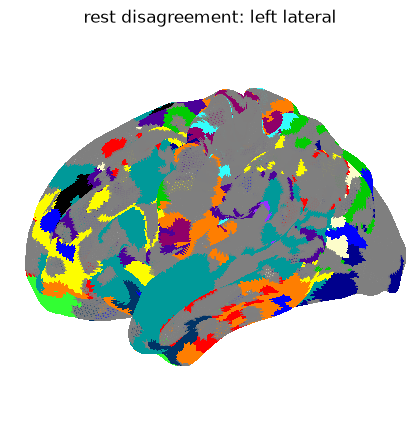

In [183]:
## TEST: plot one map / one view before building the full grid
# nilearn draws each panel in a cube sized to the brain's longest axis
# (zoom=1.3), leaving empty space above/below lateral and medial views.
# Increase panel_zoom to fill the panel; too high clips the frontal and
# occipital poles. The full figure below reuses this value.
panel_zoom = 1.5

test_map_label = next(iter(maps_to_plot))
test_hemi, test_view, test_surface_path = surface_views[0]

test_fig = plotting.plot_surf_roi(
    str(test_surface_path),
    roi_map=hemisphere_values_by_map[test_map_label][test_hemi],
    hemi=test_hemi,
    view=test_view,
    cmap=dlabel_network_cmap,
    vmin=color_min,
    vmax=color_max,
    threshold=1e-14,
    colorbar=False,
    title=f"{test_map_label}: {test_hemi} {test_view}",
)

test_fig.axes[0].set_box_aspect(None, zoom=panel_zoom)

plt.show()

In [186]:
# full figure: one row per map, one column per view, plus network legend
fig, axes = plt.subplots(
    len(maps_to_plot),
    len(surface_views),
    figsize=(
        4 * len(surface_views),
        2.6 * len(maps_to_plot),  # short rows to match wide brains
    ),
    subplot_kw={"projection": "3d"},
)

for row_index, map_label in enumerate(maps_to_plot):
    for column_index, (hemi, view, surface_path) in enumerate(
        surface_views
    ):
        ax = axes[row_index, column_index]

        plotting.plot_surf_roi(
            str(surface_path),
            roi_map=hemisphere_values_by_map[map_label][hemi],
            hemi=hemi,
            view=view,
            cmap=dlabel_network_cmap,
            vmin=color_min,
            vmax=color_max,
            threshold=1e-14,
            colorbar=False,
            axes=ax,
            figure=fig,
        )

        # must come after plot_surf_roi, which sets zoom=1.3
        ax.set_box_aspect(None, zoom=panel_zoom)

        if row_index == 0:
            ax.set_title(f"{hemi} {view}", fontsize=13)

    axes[row_index, 0].text2D(
        -0.08,
        0.5,
        map_label,
        transform=axes[row_index, 0].transAxes,
        rotation=90,
        ha="center",
        va="center",
        fontsize=14,
    )

legend_handles = [
    Patch(
        facecolor=network_colors[network_id][:3],
        edgecolor="gray",
        label=f"{network_id}: {network_labels[network_id]}",
    )
    for network_id in plotted_network_ids
]

fig.legend(
    handles=legend_handles,
    loc="center left",
    bbox_to_anchor=(0.85, 0.5),  # figure coords, just right of the grid
    frameon=False,
    fontsize=13,
)

fig.suptitle(subject, fontsize=16, y=0.98)

# tight_layout handles 3D axes poorly; set margins/gaps manually.
# Negative wspace/hspace overlap the mostly empty 3D panel boxes.
fig.subplots_adjust(
    left=0.03,
    right=0.84,  # leave room for the legend
    bottom=0.0,
    top=0.93,
    wspace=-0.05,
    hspace=-0.1,
)

plt.close(fig)  # displayed in the save cell below

Saved: /oak/stanford/groups/russpold/users/grimsrud/projects/pfm_compare/analysis/temp_match_overlap/16Sept2026_test/network_overlap_outputs/sub-s19/sub-s19_rest_vs_task_vs_task_resid_raw_disagreement_consensus_surfaces.png


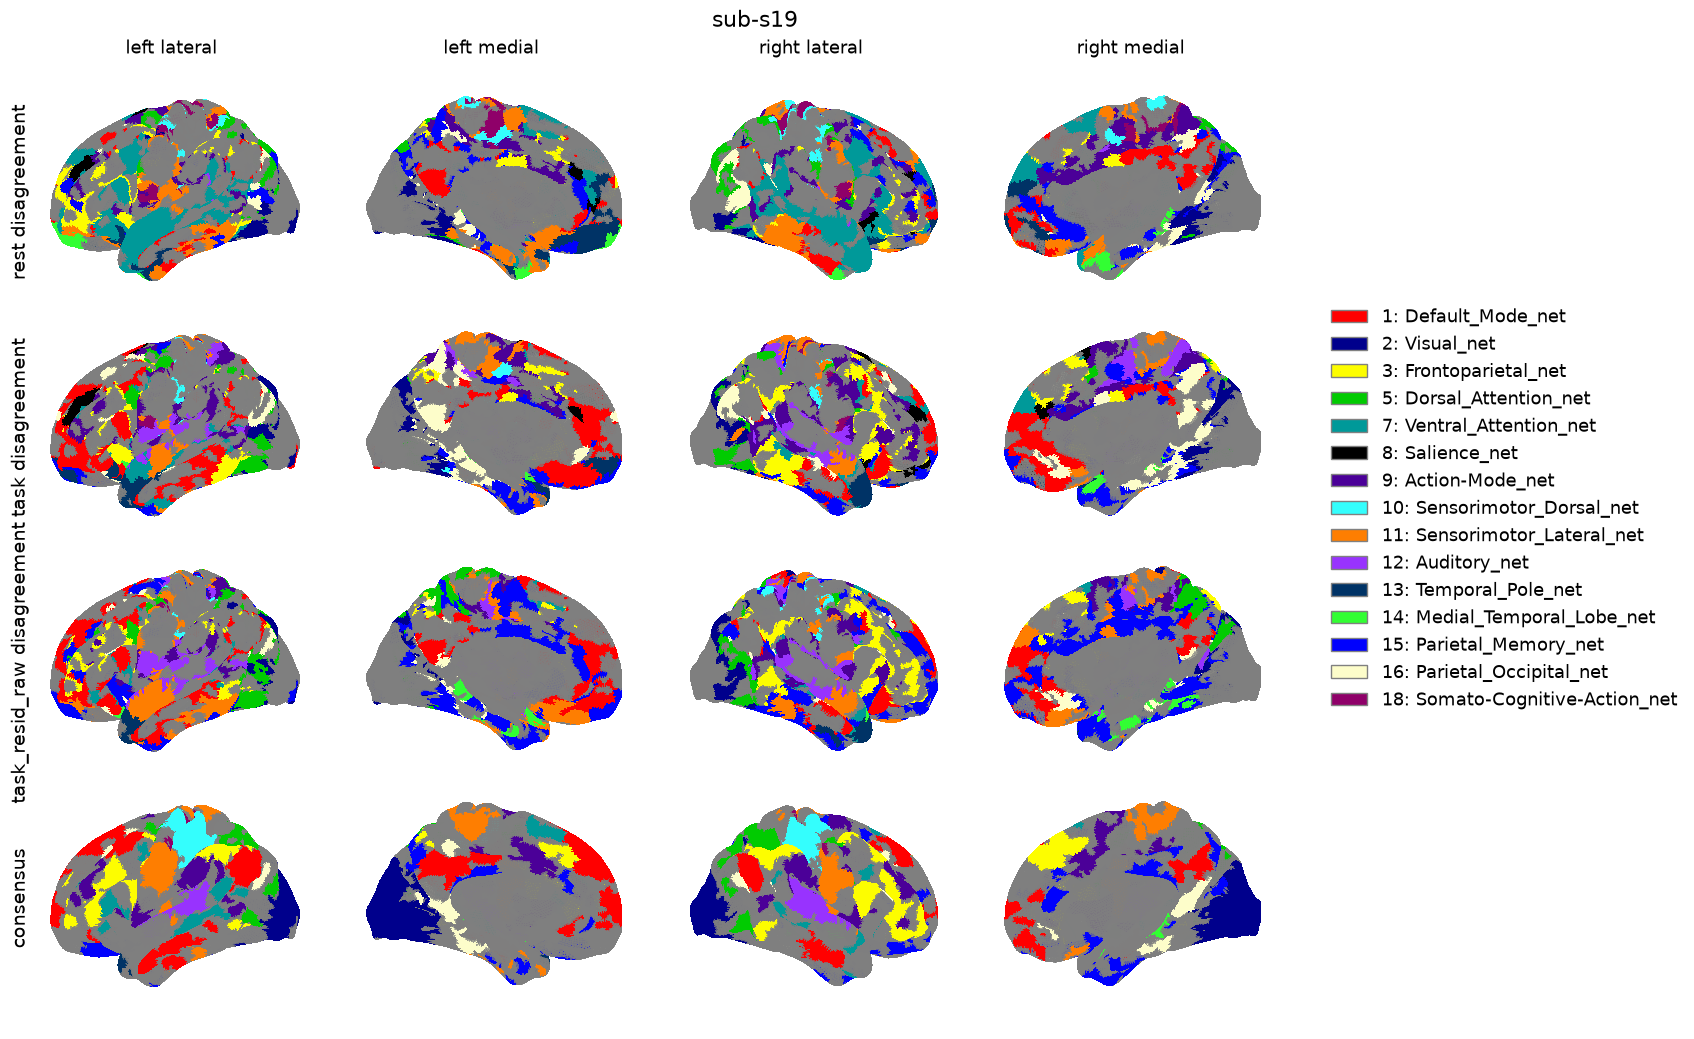

In [187]:
# save + show full figure
surface_figure_path = (
    output_directory
    / (
        f"{subject}_{comparison_name}_"
        "disagreement_consensus_surfaces.png"
    )
)

fig.savefig(
    surface_figure_path,
    dpi=150,
    bbox_inches="tight",  # crop empty figure border
    pad_inches=0.05,  # margin left after cropping
)

print("Saved:", surface_figure_path)

fig